In [ ]:
# Rule-Based Computer Vision (Traditional CVs) Usage :
# - Small Dataset (Not enough for training)
# - Segmentation (Easy than Deep Learning especially Medical, Manufacturing, Biology, v.v..)
# - Augmentation Data (Create more data for feeding to Deep Learning)
# - Quickly change Rules (Faster than training again)

In [ ]:
import os
os.listdir()

['.config',
 'MultiFace02.jpeg',
 'Coconut.jpeg',
 'Melanoma.jpeg',
 'Driving Plate.jpeg',
 'traffic sign.jpeg',
 'defect.jpeg',
 'MultiFace03.jpeg',
 'MultiFace01.jpeg',
 'Human Face 2.jpeg',
 'Human Face.jpeg',
 'sample_data']

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

def ShowImage(ImageList, nRows = 1, nCols = 2, ImageTitleList = []):
    gs = gridspec.GridSpec(nRows, nCols)
    plt.figure(figsize=(20,20))
    for i in range(len(ImageList)):
        ax = plt.subplot(gs[i])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')

        plt.subplot(nRows, nCols,i+1)

        image = ImageList[i].copy()
        if (len(image.shape) < 3):
            plt.imshow(image, plt.cm.gray)
        else:
            plt.imshow(image)
        if(len(ImageTitleList)  > 0):
          plt.title("Image " + str(ImageTitleList[i]))
        else:
          plt.title("Image " + str(i))

        plt.axis('off')

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)

def ShowHistogram(image, Title = "Color Histogram", ChannelList = ["Channel 1", "Channel 2", "Channel 3"]):
  fig, ax = plt.subplots(figsize=(20, 5))

  if(len(image.shape) == 3):
    color = ('r', 'g', 'b')
    for channel,col in enumerate(color):
        histr = cv2.calcHist([image],[channel],None,[256],[0,256])
        ax.plot(histr,color = col, label = ChannelList[channel])

    plt.title(Title)
    plt.legend()
  else:
    histr = cv2.calcHist([image],[0],None,[256],[0,256])
    plt.plot(histr,color = "gray", label = "Gray")
    plt.title("Gray Histogram")
    plt.legend()

  # Set axis ranges; by default this will put major ticks every 25.
  ax.set_xlim(0, 255)

  # Change major ticks to show every 20.
  ax.xaxis.set_major_locator(MultipleLocator(20))

  # Change minor ticks to show every 5. (20/4 = 5)
  ax.xaxis.set_minor_locator(AutoMinorLocator(4))

  # Turn grid on for both major and minor ticks and style minor slightly
  # differently.
  ax.grid(which='major', color='#CCCCCC', linestyle='--')
  ax.grid(which='minor', color='#CCCCCC', linestyle=':')
  plt.show()

In [ ]:
# Read Images
from pylab import imread
image = imread('Human Face 2.jpeg')
print(image.shape)

(667, 1000, 3)


In [ ]:
import numpy as np
RedChannel = image[:,:,0] # Red
GreenChannel = image[:,:,1] # Green
BlueChannel = image[:,:,2] # Blue
[np.min(GreenChannel), np.max(GreenChannel)]

[0, 250]

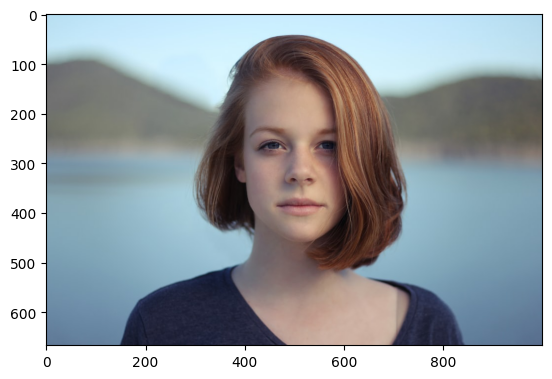

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(image)

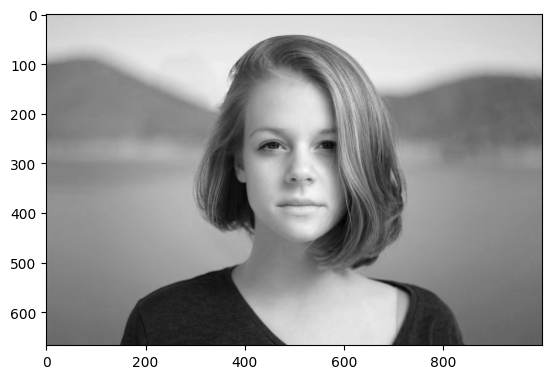

In [ ]:
plt.imshow(RedChannel, cmap = "gray")

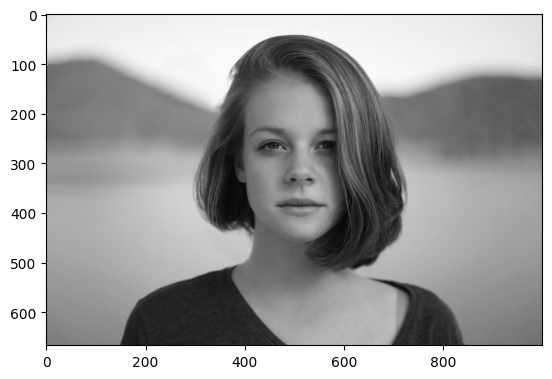

In [ ]:
plt.imshow(GreenChannel, plt.cm.gray)

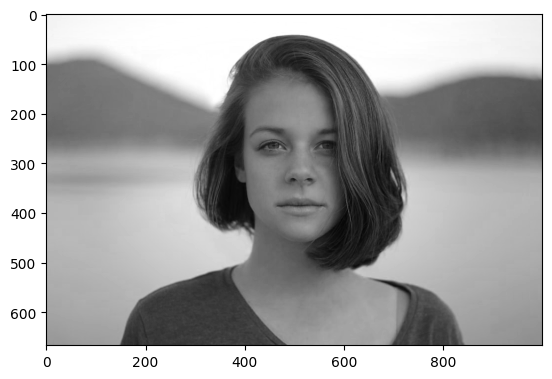

In [ ]:
plt.imshow(BlueChannel, plt.cm.gray)

In [ ]:
import cv2
image_HSV = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
HueChannel = image_HSV[:,:,0]
SaturationChannel = image_HSV[:,:,1]
ValueChannel = image_HSV[:,:,2]

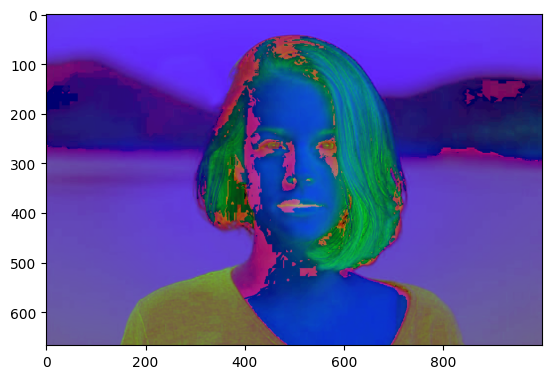

In [ ]:
plt.imshow(image_HSV)

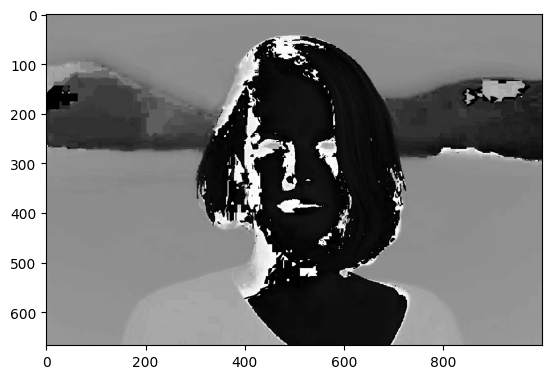

In [ ]:
plt.imshow(HueChannel, plt.cm.gray)

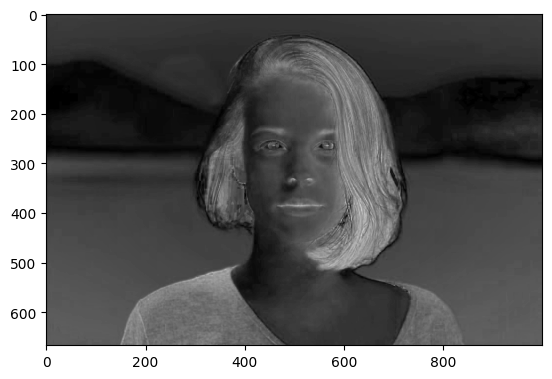

In [ ]:
plt.imshow(SaturationChannel, plt.cm.gray)

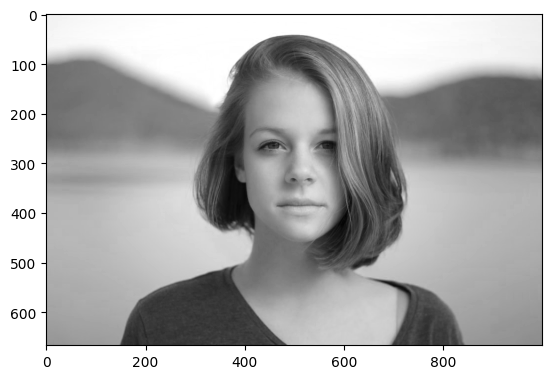

In [ ]:
plt.imshow(ValueChannel, plt.cm.gray)

In [ ]:
# from skimage.transform import rescale, resize
import cv2

def ResizeImage(image, wresize = 0, hresize = 0):
  OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])

  if((wresize == 0) & (hresize == 0)):
      return image
  if(wresize == 0):
      wresize = int((OrigWidth * hresize)/OrigHeight)
  if(hresize == 0):
      hresize = int((OrigHeight * wresize)/OrigWidth)
  resize_image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
  return resize_image

def ConvertColorSpaces(image, ColorSpace = "GRAY", display = 1):
  ImageTitleList = ["RGB", ColorSpace]

  if(ColorSpace.upper() == "HSV"):
    image_convert = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ChannelList = ["Chrominance Hue" , "Chrominance Saturation", "Luminance Value"]
  elif(ColorSpace.upper() == "YCRCB"):
    image_convert = cv2.cvtColor(image, cv2.COLOR_RGB2YCR_CB)
    ChannelList = ["Chrominance Red" , "Chrominance Blue", "Luminance Y"]
  elif(ColorSpace.upper() == "LAB"):
    image_convert = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    ChannelList = ["Chrominance a(Green To Red)" , "Chrominance b(Blue To Yellow)", "Luminance L"]
  else:
    image_convert = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    ChannelList = ["Gray Information"]
  return image_convert, ChannelList

In [ ]:
print(image.shape)
resize_image = ResizeImage(image, wresize = 500, hresize = 0)
print(resize_image.shape)

image_gray, ChannelListGRAY = ConvertColorSpaces(resize_image, ColorSpace = "GRAY")
image_hsv, ChannelListHSV = ConvertColorSpaces(resize_image, ColorSpace = "HSV")
image_ycrcb, ChannelListYcbcr = ConvertColorSpaces(resize_image, ColorSpace = "YCrCb")
image_lab, ChannelListLab = ConvertColorSpaces(resize_image, ColorSpace = "Lab")

(667, 1000, 3)
(333, 500, 3)


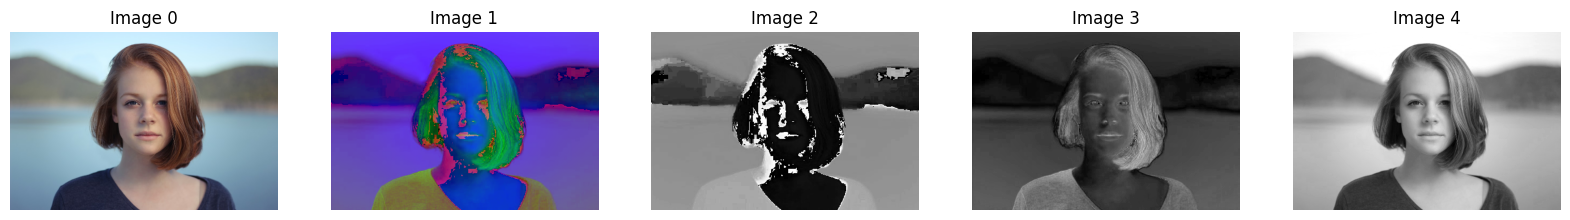

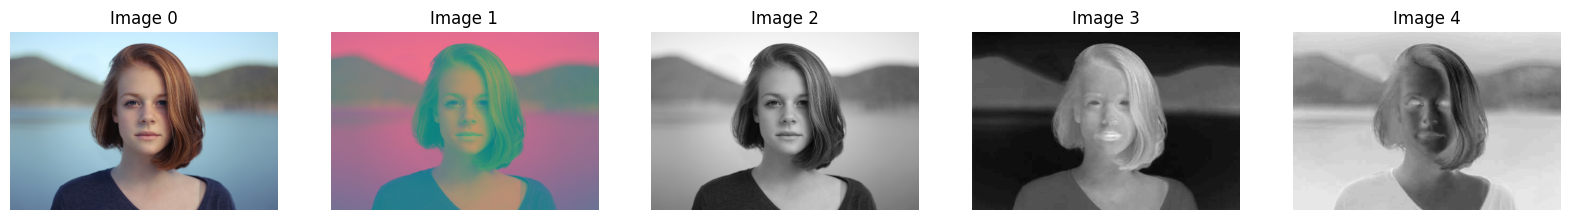

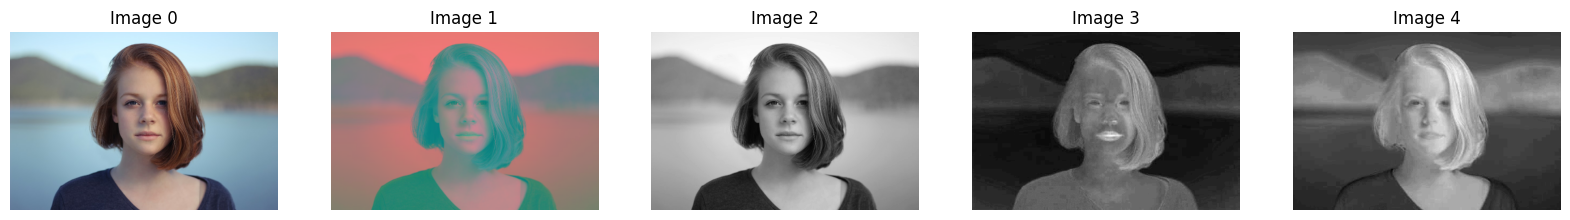

In [ ]:
ShowImage([resize_image, image_hsv, image_hsv[:,:,0], image_hsv[:,:,1], image_hsv[:,:,2]], 1, 5)
ShowImage([resize_image, image_ycrcb, image_ycrcb[:,:,0], image_ycrcb[:,:,1], image_ycrcb[:,:,2]], 1, 5)
ShowImage([resize_image, image_lab, image_lab[:,:,0], image_lab[:,:,1], image_lab[:,:,2]], 1, 5)

In [ ]:
from skimage.morphology import (erosion, dilation, opening, closing, white_tophat)
from skimage.morphology import black_tophat, skeletonize, convex_hull_image
from skimage.morphology import disk
from scipy import ndimage
import cv2

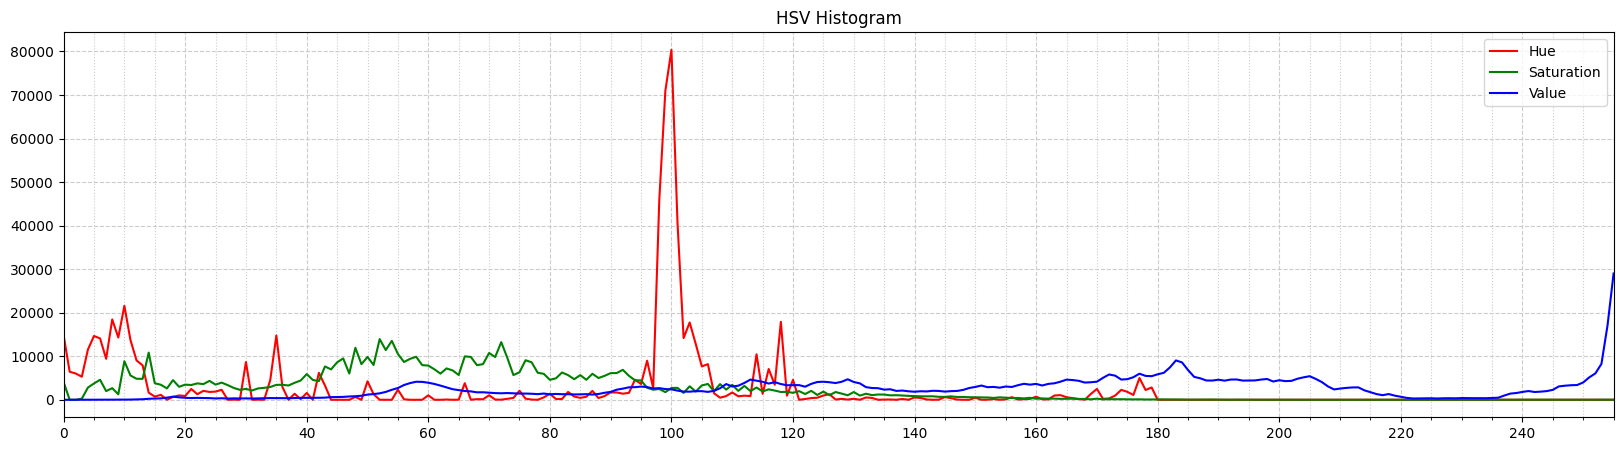

In [ ]:
ShowHistogram(image_HSV, Title = "HSV Histogram", ChannelList = ["Hue", "Saturation", "Value"])

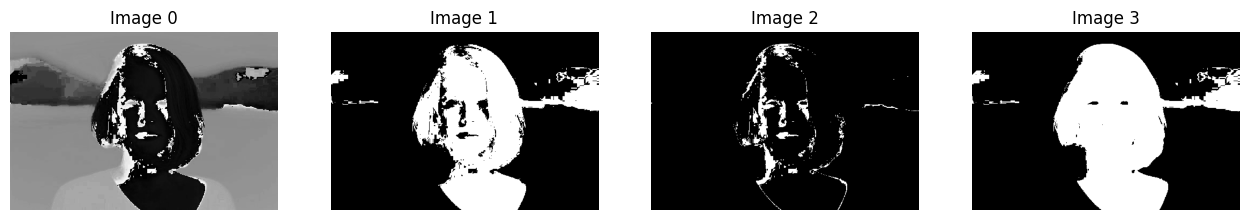

[0 1]


In [ ]:
import numpy as np
# Binary Image
HueChannel = image_hsv[:,:,0]
ValueChannel = image_hsv[:,:,2]

Mask1 = (HueChannel < 30).astype(int)
Mask2 = (HueChannel > 150).astype(int)
Mask3 = (Mask1 | Mask2)
ShowImage([HueChannel, Mask1, Mask2, Mask3], 1, 5)
print(np.unique(Mask3))

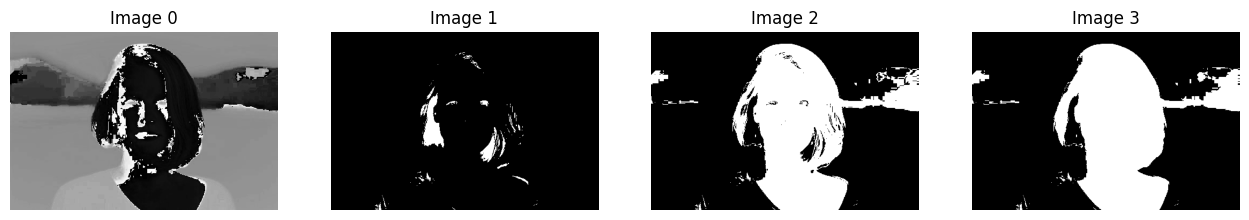

[0 1]


In [ ]:
Mask4 = (ValueChannel < 50).astype(int)
Mask5 = Mask3 ^ Mask4
Mask6 = ndimage.binary_fill_holes(Mask5).astype(int)
ShowImage([HueChannel, Mask4, Mask5, Mask6], 1, 5)
print(np.unique(Mask6))

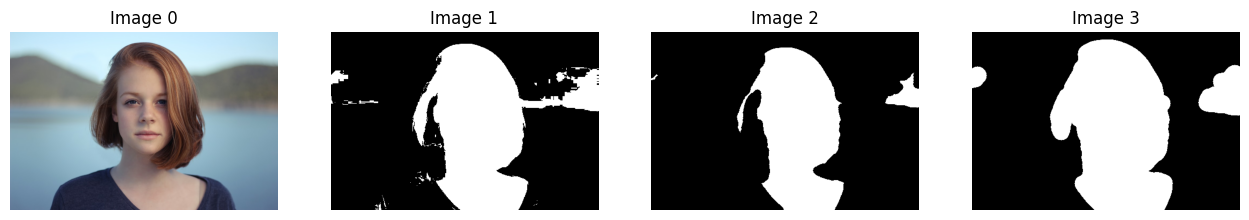

[0 1]


In [ ]:
size = 7
kernel = disk(abs(size))
Mask7 = erosion(Mask6,  disk(abs(size)))

size = 15
kernel = disk(abs(size))
Mask8 = dilation(Mask7, kernel)
ShowImage([image, Mask6, Mask7, Mask8], 1, 5)
print(np.unique(Mask8))

In [ ]:
import skimage
from skimage import measure

image_mask = Mask8
labels_mask = measure.label(image_mask)
IndexList = np.unique(labels_mask)
print(IndexList)

[0 1 2 3]


In [ ]:
labels_mask.shape

(333, 500)

In [ ]:
index_images = []
for idx in IndexList:
  image_idx = (labels_mask == idx).astype(int)
  index_images.append(image_idx)

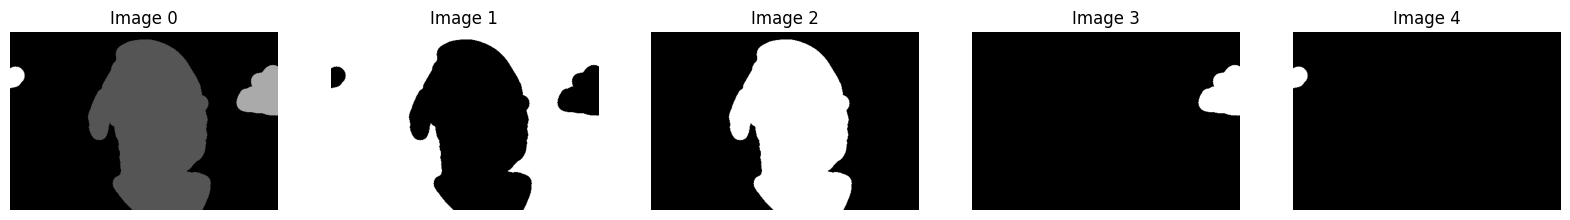

In [ ]:
ShowImage([labels_mask] + index_images, 1, len(index_images) + 1)

In [ ]:
from skimage.measure import label, regionprops
import pandas as pd

image_label = label(image_mask)
regions = regionprops(image_label, intensity_image=image_gray)

ColList = ["label", "at_row", "at_col",
          "area", "minr", "minc", "maxr", "maxc", "width", "height",
           "max_intensity", "mean_intensity", "min_intensity",]

LabelDF = pd.DataFrame(columns = ColList)
for props in regions:
    RowList = []
    label = props.label
    if("label" in ColList):
        RowList.append(label)

    at_row, at_col = props.centroid
    if("at_row" in ColList):
        RowList.append(at_row)

    if("at_col" in ColList):
        RowList.append(at_col)

    if("area" in ColList):
        RowList.append(props.area)

    minr, minc, maxr, maxc = props.bbox
    if("minr" in ColList):
        RowList.append(minr)

    if("minc" in ColList):
        RowList.append(minc)

    if("maxr" in ColList):
        RowList.append(maxr)

    if("maxc" in ColList):
        RowList.append(maxc)

    if("width" in ColList):
        RowList.append(maxc - minc)

    if("height" in ColList):
        RowList.append(maxr - minr)

    if("max_intensity" in ColList):
        RowList.append(props.max_intensity)

    if("mean_intensity" in ColList):
        RowList.append(props.mean_intensity)

    if("min_intensity" in ColList):
        RowList.append(props.min_intensity)

    LabelDF.loc[label-1, 0 : len(RowList)] = RowList

<ipython-input-30-9bfc94486d4a>:56: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList
<ipython-input-30-9bfc94486d4a>:56: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList
<ipython-input-30-9bfc94486d4a>:56: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList


In [ ]:
LabelDF = LabelDF.sort_values(by = "area", ascending = False)
LabelDF.head()

,label,at_row,at_col,area,minr,minc,maxr,maxc,width,height,max_intensity,mean_intensity,min_intensity
0,1,177.341228,269.140234,53161,14,145,333,375,230,319,240.0,112.696375,2.0
1,2,114.490442,468.516509,5179,61,422,157,500,78,96,157.0,101.214906,83.0
2,3,83.163429,11.355429,875,64,0,105,28,28,41,117.0,113.264,107.0


In [ ]:
idx = LabelDF.loc[0, "label"]
minr, minc = LabelDF.loc[0, "minr"], LabelDF.loc[0, "minc"]
maxr, maxc = LabelDF.loc[0, "maxr"], LabelDF.loc[0, "maxc"]
left_top = (minc, minr)
right_bottom = (maxc, maxr)

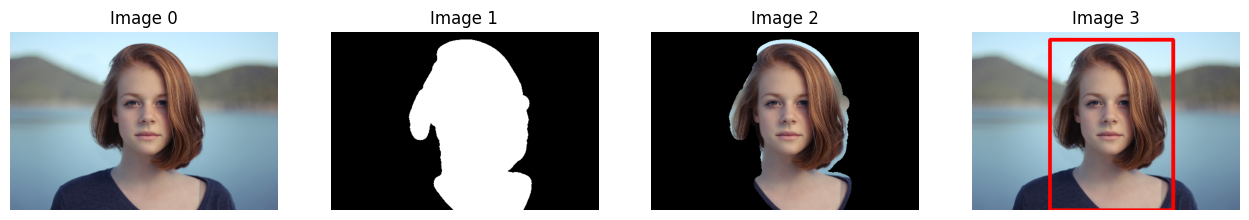

In [ ]:
Mask9 = (image_label == idx).astype(np.uint8)
CropFaceIM = cv2.bitwise_and(resize_image, resize_image, mask = Mask9.astype(np.uint8))

image_output = resize_image.copy()
cv2.rectangle(image_output,left_top, right_bottom, (255,0,0) , 5)
ShowImage([resize_image, Mask9, CropFaceIM, image_output], 1, 5)

(1125, 1500, 3)
(375, 500, 3)


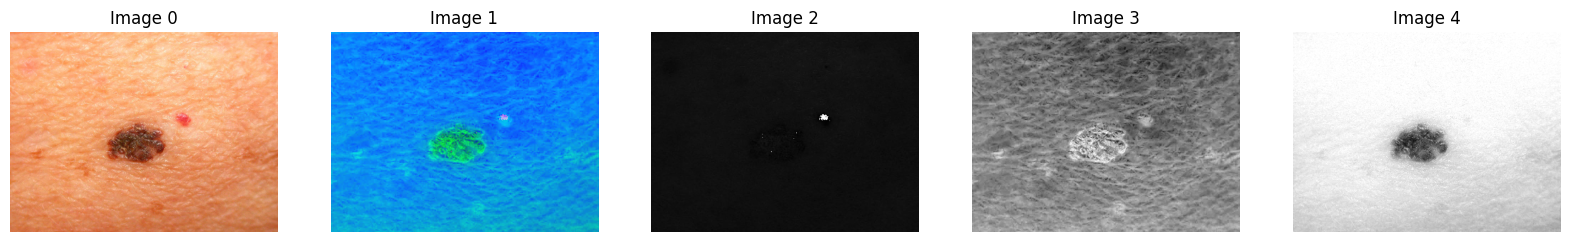

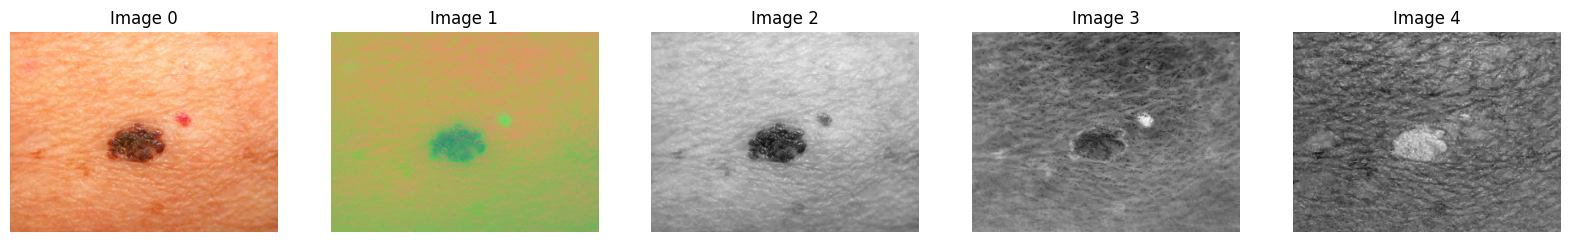

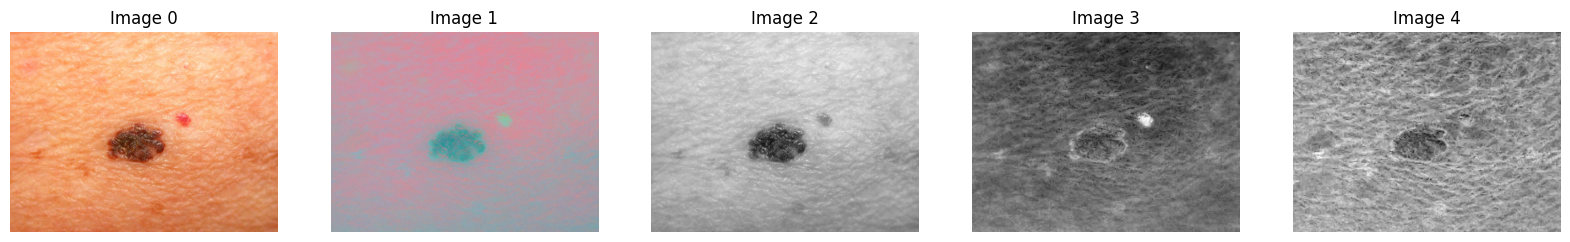

In [ ]:
# Melanoma
image = imread('Melanoma.jpeg')
print(image.shape)

resize_image = ResizeImage(image, wresize = 500, hresize = 0)
print(resize_image.shape)

image_gray, ChannelListGRAY = ConvertColorSpaces(resize_image, ColorSpace = "GRAY")
image_hsv, ChannelListHSV = ConvertColorSpaces(resize_image, ColorSpace = "HSV")
image_ycrcb, ChannelListYcbcr = ConvertColorSpaces(resize_image, ColorSpace = "YCrCb")
image_lab, ChannelListLab = ConvertColorSpaces(resize_image, ColorSpace = "Lab")

ShowImage([resize_image, image_hsv, image_hsv[:,:,0], image_hsv[:,:,1], image_hsv[:,:,2]], 1, 5)
ShowImage([resize_image, image_ycrcb, image_ycrcb[:,:,0], image_ycrcb[:,:,1], image_ycrcb[:,:,2]], 1, 5)
ShowImage([resize_image, image_lab, image_lab[:,:,0], image_lab[:,:,1], image_lab[:,:,2]], 1, 5)

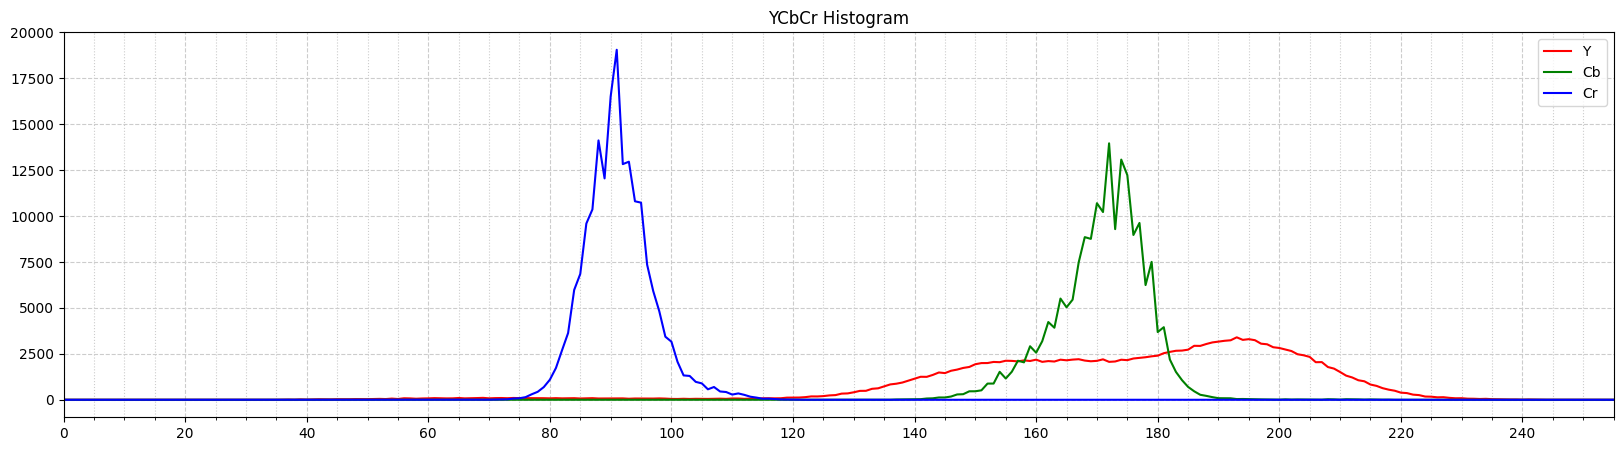

In [ ]:
ShowHistogram(image_ycrcb, Title = "YCbCr Histogram", ChannelList = ["Y", "Cb", "Cr"])

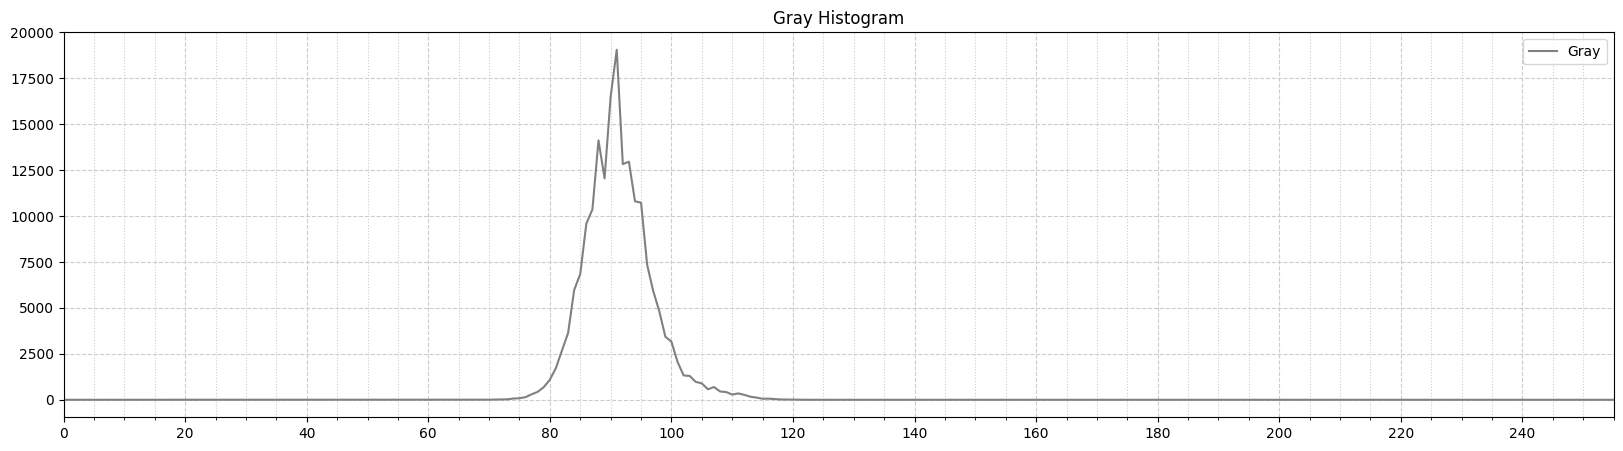

In [ ]:
CrChannel = image_ycrcb[:,:,2]
ShowHistogram(CrChannel, Title = "Cr Histogram")

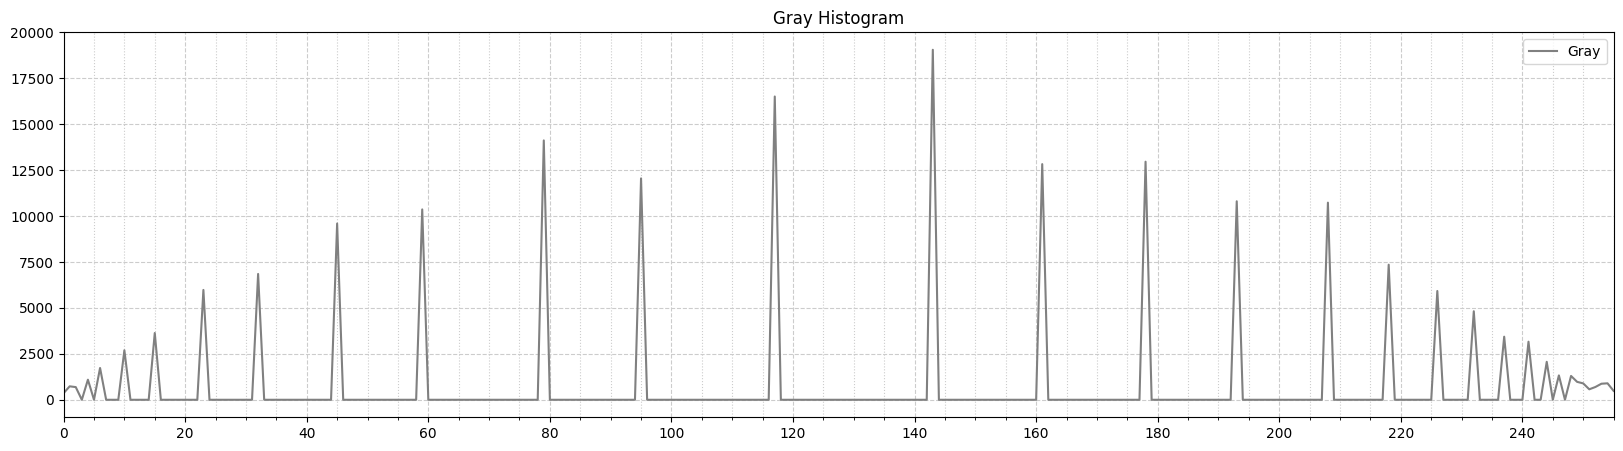

In [ ]:
CrChannel_EqualHist = cv2.equalizeHist(CrChannel)
ShowHistogram(CrChannel_EqualHist, Title = "Equalization Cr Histogram")

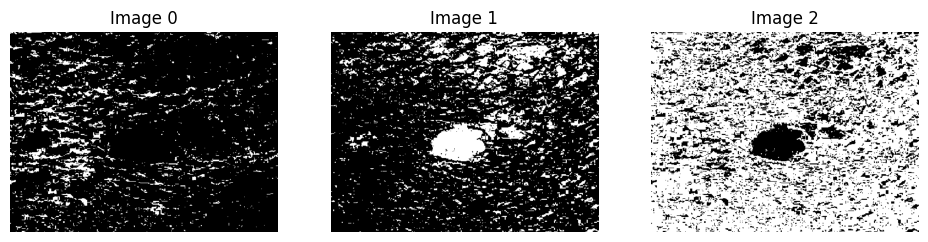

In [ ]:
Mask1 = (CrChannel < 85).astype(int)
Mask2 = (CrChannel > 95).astype(int)
Mask3 = 1 - (Mask1 | Mask2)

ShowImage([Mask1, Mask2, Mask3], 1, 5)

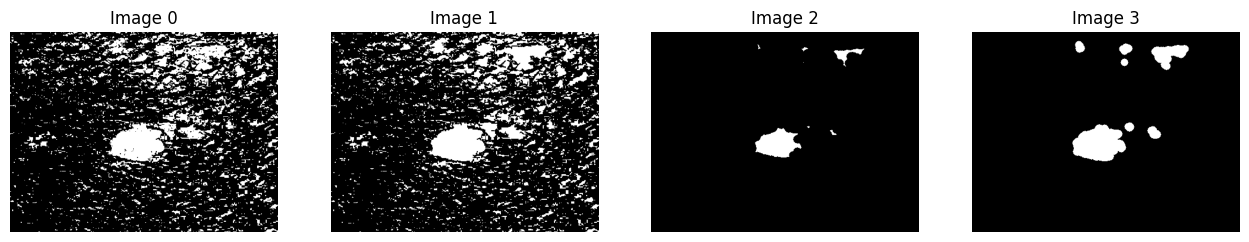

In [ ]:
Mask4 = ndimage.binary_fill_holes(Mask2).astype(int)

size = 7
kernel = disk(abs(size))
Mask5 = erosion(Mask4,  disk(abs(size)))

size = 7
kernel = disk(abs(size))
Mask6 = dilation(Mask5, kernel)

ShowImage([Mask2, Mask4, Mask5, Mask6], 1, 5)

In [ ]:
del label

In [ ]:
from skimage import measure

In [ ]:
image_mask = Mask6
YChannel = image_ycrcb[:,:,0]
image_label = measure.label(image_mask)
regions = regionprops(image_label, intensity_image=YChannel)

ColList = ["label", "at_row", "at_col",
          "area", "minr", "minc", "maxr", "maxc", "width", "height",
           "max_intensity", "mean_intensity", "min_intensity",]

LabelDF = pd.DataFrame(columns = ColList)
for props in regions:
    RowList = []
    label = props.label
    if("label" in ColList):
        RowList.append(label)

    at_row, at_col = props.centroid
    if("at_row" in ColList):
        RowList.append(at_row)

    if("at_col" in ColList):
        RowList.append(at_col)

    if("area" in ColList):
        RowList.append(props.area)

    minr, minc, maxr, maxc = props.bbox
    if("minr" in ColList):
        RowList.append(minr)

    if("minc" in ColList):
        RowList.append(minc)

    if("maxr" in ColList):
        RowList.append(maxr)

    if("maxc" in ColList):
        RowList.append(maxc)

    if("width" in ColList):
        RowList.append(maxc - minc)

    if("height" in ColList):
        RowList.append(maxr - minr)

    if("max_intensity" in ColList):
        RowList.append(props.max_intensity)

    if("mean_intensity" in ColList):
        RowList.append(props.mean_intensity)

    if("min_intensity" in ColList):
        RowList.append(props.min_intensity)

    LabelDF.loc[label-1, 0 : len(RowList)] = RowList

<ipython-input-71-4a69413bd72b>:55: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList
<ipython-input-71-4a69413bd72b>:55: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList
<ipython-input-71-4a69413bd72b>:55: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label-1, 0 : len(RowList)] = RowList
<ipython-input-71-4a69413bd72b>:55: FutureWarning: Slicing a positional slice with .loc is not supported, and will raise TypeError in a future version.  Use .loc with labels or .iloc with positions instead.
  LabelDF.loc[label

In [ ]:
display(LabelDF)

,label,at_row,at_col,area,minr,minc,maxr,maxc,width,height,max_intensity,mean_intensity,min_intensity
0,1,29.26,200.533333,300,18,192,41,211,19,23,235.0,214.673333,199.0
1,2,33.057065,286.304348,368,23,274,45,300,26,22,249.0,218.42663,199.0
2,3,43.133889,366.682222,1800,26,334,73,405,71,47,240.0,214.921111,195.0
3,4,58.0,284.0,149,51,277,66,292,15,15,235.0,218.483221,208.0
4,5,178.480519,293.207792,231,170,284,188,303,19,18,242.0,194.861472,172.0
5,6,209.953704,236.690947,4860,174,187,243,288,101,69,244.0,84.113992,25.0
6,7,189.34375,339.211538,416,177,327,201,353,26,24,231.0,202.649038,181.0


In [ ]:
LabelDF = LabelDF.sort_values(by = "mean_intensity", ascending = True)
LabelDF = LabelDF.reset_index(drop = True)
LabelDF.head()

,label,at_row,at_col,area,minr,minc,maxr,maxc,width,height,max_intensity,mean_intensity,min_intensity
0,6,209.953704,236.690947,4860,174,187,243,288,101,69,244.0,84.113992,25.0
1,5,178.480519,293.207792,231,170,284,188,303,19,18,242.0,194.861472,172.0
2,7,189.34375,339.211538,416,177,327,201,353,26,24,231.0,202.649038,181.0
3,1,29.26,200.533333,300,18,192,41,211,19,23,235.0,214.673333,199.0
4,3,43.133889,366.682222,1800,26,334,73,405,71,47,240.0,214.921111,195.0


In [ ]:
idx = LabelDF.loc[0, "label"]
minr, minc = LabelDF.loc[0, "minr"], LabelDF.loc[0, "minc"]
maxr, maxc = LabelDF.loc[0, "maxr"], LabelDF.loc[0, "maxc"]
padding = 5
left_top = (minc - padding, minr - padding)
right_bottom = (maxc + padding, maxr + padding)

In [ ]:
idx

6

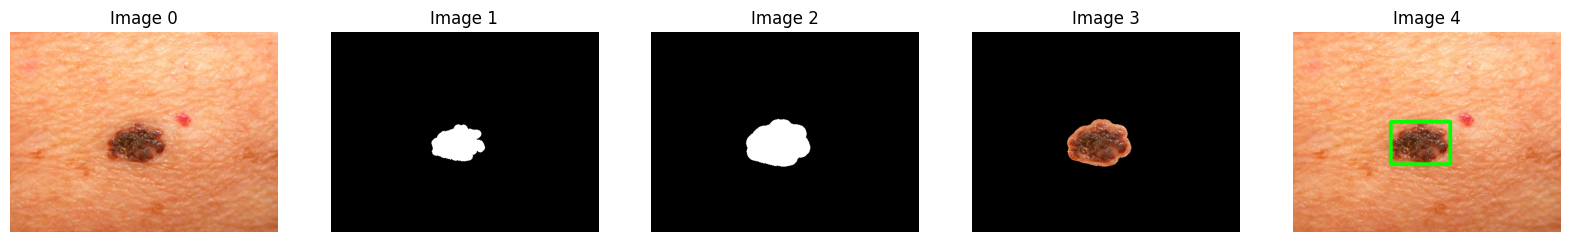

In [ ]:
Mask7 = (image_label == idx).astype(np.uint8)

size = 10
kernel = disk(abs(size))
Mask8 = dilation(Mask7, kernel)

CropMelanomaIM = cv2.bitwise_and(resize_image, resize_image, mask = Mask8.astype(np.uint8))

image_output = resize_image.copy()
cv2.rectangle(image_output,left_top, right_bottom, (0,255,0) , 5)
ShowImage([resize_image, Mask7, Mask8, CropMelanomaIM, image_output], 1, 5)